# JSON → IFC4 translator

Turns the canonical building JSON (walls as centerlines, doors/windows by offset along a wall, rooms as boundary polygons) into a valid **IFC4** model using IfcOpenShell.

**How to use**
1. Run the install cell.
2. Run the translator cell (defines `build_ifc`).
3. Upload your JSON File via file picker
4. Run *Build & download* to get `model.ifc`.

Expected JSON shape:
```json
{
  "project": { "name": "..." },
  "storeys": [ { "id": "L0", "name": "Ground Floor", "elevation": 0.0 } ],
  "walls":   [ { "id": "S", "storey": "L0", "start": [0,0], "end": [5,0], "height": 3.0, "thickness": 0.2 } ],
  "doors":   [ { "id": "D1", "wall": "S", "offset": 2.5, "width": 0.9, "height": 2.1 } ],
  "windows": [ { "id": "W1", "wall": "S", "offset": 4.0, "width": 1.0, "height": 1.2, "sill_height": 0.9 } ],
  "rooms":   [ { "id": "R1", "storey": "L0", "name": "Room", "boundary": [[0,0],[5,0],[5,4],[0,4]], "height": 3.0 } ]
}
```
Walls reference a storey by `id`; doors/windows reference their host wall by `id` and are positioned by `offset` *along* that wall. Rooms accept any closed polygon (e.g. L-shaped), not just rectangles.

## 0. Install

In [73]:
!pip install ifcopenshell -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 MB 21.8 MB/s eta 0:00:00:00:0100:01


## 1. The translator
Run once; defines `build_ifc(data, out_path, add_floor_slabs, slab_thickness)`.

In [ ]:
"""Generalized JSON -> IFC4 translator (core logic, tested locally)."""
import math
import ifcopenshell
import ifcopenshell.guid
import ifcopenshell.api.context
import ifcopenshell.api.unit
import ifcopenshell.api.root
import ifcopenshell.api.aggregate
import ifcopenshell.api.spatial


def _dir(m, v):
    return m.create_entity("IfcDirection", DirectionRatios=[float(x) for x in v])


def _pt(m, v):
    return m.create_entity("IfcCartesianPoint", Coordinates=[float(x) for x in v])


def _ax2(m, loc=(0.0, 0.0)):
    return m.create_entity("IfcAxis2Placement2D", Location=_pt(m, loc))


def _ax3(m, loc=(0, 0, 0), z=(0, 0, 1), x=(1, 0, 0)):
    return m.create_entity("IfcAxis2Placement3D", Location=_pt(m, loc),
                           Axis=_dir(m, z), RefDirection=_dir(m, x))


def _place(m, loc=(0, 0, 0), x=(1, 0, 0), rel_to=None):
    return m.create_entity("IfcLocalPlacement", PlacementRelTo=rel_to,
                           RelativePlacement=_ax3(m, loc, (0, 0, 1), x))


def _box(m, body, xdim, ydim, height, center=(0.0, 0.0)):
    prof = m.create_entity("IfcRectangleProfileDef", ProfileType="AREA",
                           Position=_ax2(m, center), XDim=float(xdim), YDim=float(ydim))
    solid = m.create_entity("IfcExtrudedAreaSolid", SweptArea=prof, Position=_ax3(m),
                            ExtrudedDirection=_dir(m, (0, 0, 1)), Depth=float(height))
    rep = m.create_entity("IfcShapeRepresentation", ContextOfItems=body,
                          RepresentationIdentifier="Body", RepresentationType="SweptSolid",
                          Items=[solid])
    return m.create_entity("IfcProductDefinitionShape", Representations=[rep])


def _polygon(m, body, pts, height):
    ifc_pts = [_pt(m, (p[0], p[1])) for p in pts]
    ifc_pts.append(ifc_pts[0])  # close the loop
    curve = m.create_entity("IfcPolyline", Points=ifc_pts)
    prof = m.create_entity("IfcArbitraryClosedProfileDef", ProfileType="AREA", OuterCurve=curve)
    solid = m.create_entity("IfcExtrudedAreaSolid", SweptArea=prof, Position=_ax3(m),
                            ExtrudedDirection=_dir(m, (0, 0, 1)), Depth=float(height))
    rep = m.create_entity("IfcShapeRepresentation", ContextOfItems=body,
                          RepresentationIdentifier="Body", RepresentationType="SweptSolid",
                          Items=[solid])
    return m.create_entity("IfcProductDefinitionShape", Representations=[rep])


def _voids(m, wall, opening):
    m.create_entity("IfcRelVoidsElement", GlobalId=ifcopenshell.guid.new(),
                    RelatingBuildingElement=wall, RelatedOpeningElement=opening)


def _fills(m, opening, elem):
    m.create_entity("IfcRelFillsElement", GlobalId=ifcopenshell.guid.new(),
                    RelatingOpeningElement=opening, RelatedBuildingElement=elem)


def build_ifc(data, out_path="model.ifc", add_floor_slabs=True, slab_thickness=0.2):
    """Translate the canonical room/wall/opening JSON into an IFC4 file."""
    m = ifcopenshell.file(schema="IFC4")
    project = ifcopenshell.api.root.create_entity(
        m, ifc_class="IfcProject", name=data.get("project", {}).get("name", "Project"))
    ifcopenshell.api.unit.assign_unit(m, units=[
        ifcopenshell.api.unit.add_si_unit(m, unit_type="LENGTHUNIT"),
        ifcopenshell.api.unit.add_si_unit(m, unit_type="AREAUNIT"),
        ifcopenshell.api.unit.add_si_unit(m, unit_type="VOLUMEUNIT"),
    ])
    ctx = ifcopenshell.api.context.add_context(m, context_type="Model")
    body = ifcopenshell.api.context.add_context(
        m, context_type="Model", context_identifier="Body",
        target_view="MODEL_VIEW", parent=ctx)

    site = ifcopenshell.api.root.create_entity(m, ifc_class="IfcSite", name="Site")
    building = ifcopenshell.api.root.create_entity(m, ifc_class="IfcBuilding", name="Building")
    ifcopenshell.api.aggregate.assign_object(m, products=[site], relating_object=project)
    ifcopenshell.api.aggregate.assign_object(m, products=[building], relating_object=site)

    storeys, elevations = {}, {}
    for s in data.get("storeys", []):
        st = ifcopenshell.api.root.create_entity(m, ifc_class="IfcBuildingStorey", name=s.get("name"))
        st.Elevation = float(s.get("elevation", 0.0))
        ifcopenshell.api.aggregate.assign_object(m, products=[st], relating_object=building)
        storeys[s["id"]] = st
        elevations[s["id"]] = float(s.get("elevation", 0.0))
    if not storeys:  # tolerate a storey-less file
        st = ifcopenshell.api.root.create_entity(m, ifc_class="IfcBuildingStorey", name="Storey")
        st.Elevation = 0.0
        ifcopenshell.api.aggregate.assign_object(m, products=[st], relating_object=building)
        storeys["__default__"] = st
        elevations["__default__"] = 0.0

    def storey_of(key):
        return key if key in storeys else next(iter(storeys))

    contained = {k: [] for k in storeys}  # storey_id -> physical elements
    walls = {}

    for w in data.get("walls", []):
        sk = storey_of(w.get("storey"))
        z0 = elevations[sk]
        sx, sy = w["start"]
        ex, ey = w["end"]
        dx, dy = ex - sx, ey - sy
        length = math.hypot(dx, dy)
        ux, uy = (dx / length, dy / length) if length else (1.0, 0.0)
        wall = ifcopenshell.api.root.create_entity(m, ifc_class="IfcWall", name=f"Wall-{w['id']}")
        wall.Representation = _box(m, body, length, w["thickness"], w["height"],
                                   center=(length / 2.0, 0.0))
        wall.ObjectPlacement = _place(m, loc=(sx, sy, z0), x=(ux, uy, 0.0))
        walls[w["id"]] = {"e": wall, "storey": sk}
        contained[sk].append(wall)

    def add_opening(spec, kind):
        host = walls[spec["wall"]]
        wall = host["e"]
        sk = host["storey"]
        sill = float(spec.get("sill_height", 0.0))
        depth = 1.0  # generous over-cut; trimmed by the wall boolean
        op = ifcopenshell.api.root.create_entity(m, ifc_class="IfcOpeningElement",
                                                 name=f"Opening-{spec['id']}")
        op.PredefinedType = "OPENING"
        op.Representation = _box(m, body, spec["width"], depth, spec["height"])
        op.ObjectPlacement = _place(m, loc=(spec["offset"], 0.0, sill),
                                    rel_to=wall.ObjectPlacement)
        _voids(m, wall, op)
        cls = "IfcDoor" if kind == "door" else "IfcWindow"
        elem = ifcopenshell.api.root.create_entity(m, ifc_class=cls, name=f"{kind.title()}-{spec['id']}")
        elem.OverallHeight = float(spec["height"])
        elem.OverallWidth = float(spec["width"])
        elem.Representation = _box(m, body, spec["width"], 0.05 if kind == "door" else 0.03,
                                   spec["height"])
        elem.ObjectPlacement = _place(m, loc=(0.0, 0.0, 0.0), rel_to=op.ObjectPlacement)
        _fills(m, op, elem)
        contained[sk].append(elem)

    for d in data.get("doors", []):
        add_opening(d, "door")
    for w in data.get("windows", []):
        add_opening(w, "window")

    for r in data.get("rooms", []):
        sk = storey_of(r.get("storey"))
        z0 = elevations[sk]
        space = ifcopenshell.api.root.create_entity(m, ifc_class="IfcSpace", name=r.get("name", r["id"]))
        space.PredefinedType = "INTERNAL"
        space.Representation = _polygon(m, body, r["boundary"], r["height"])
        space.ObjectPlacement = _place(m, loc=(0.0, 0.0, z0))
        ifcopenshell.api.aggregate.assign_object(m, products=[space], relating_object=storeys[sk])
        if add_floor_slabs:
            slab = ifcopenshell.api.root.create_entity(m, ifc_class="IfcSlab", name=f"Floor-{r['id']}")
            slab.PredefinedType = "FLOOR"
            slab.Representation = _polygon(m, body, r["boundary"], slab_thickness)
            slab.ObjectPlacement = _place(m, loc=(0.0, 0.0, z0 - slab_thickness))
            contained[sk].append(slab)

    for sk, items in contained.items():
        if items:
            ifcopenshell.api.spatial.assign_container(m, products=items, relating_structure=storeys[sk])

    m.write(out_path)
    counts = {c: len(m.by_type(c)) for c in
              ["IfcWall", "IfcDoor", "IfcWindow", "IfcSlab", "IfcSpace", "IfcBuildingStorey"]}
    print(f"Wrote {out_path}  ->  {counts}")
    return out_path



In [82]:
from google.colab import files
yahoo = files.download('/content/drive/MyDrive/ONESTRUCTION/building.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Your data

In [83]:
SAMPLE = {
    "project": {
        "name": "Simple Room"
    },
    "storeys": [
        {
            "id": "L0",
            "name": "Ground Floor",
            "elevation": 0.0
        }
    ],
    "walls": [
        {
            "id": "S",
            "storey": "L0",
            "start": [
                0.0,
                0.0
            ],
            "end": [
                5.0,
                0.0
            ],
            "height": 3.0,
            "thickness": 0.2
        },
        {
            "id": "E",
            "storey": "L0",
            "start": [
                5.0,
                0.0
            ],
            "end": [
                5.0,
                4.0
            ],
            "height": 3.0,
            "thickness": 0.2
        },
        {
            "id": "N",
            "storey": "L0",
            "start": [
                5.0,
                4.0
            ],
            "end": [
                0.0,
                4.0
            ],
            "height": 3.0,
            "thickness": 0.2
        },
        {
            "id": "W",
            "storey": "L0",
            "start": [
                0.0,
                4.0
            ],
            "end": [
                0.0,
                0.0
            ],
            "height": 3.0,
            "thickness": 0.2
        }
    ],
    "doors": [
        {
            "id": "D1",
            "wall": "S",
            "offset": 2.5,
            "width": 0.9,
            "height": 2.1
        }
    ],
    "windows": [
        {
            "id": "Win1",
            "wall": "S",
            "offset": 4.0,
            "width": 1.0,
            "height": 1.2,
            "sill_height": 0.9
        },
        {
            "id": "Win2",
            "wall": "E",
            "offset": 2.0,
            "width": 1.2,
            "height": 1.2,
            "sill_height": 0.9
        }
    ],
    "rooms": [
        {
            "id": "R1",
            "storey": "L0",
            "name": "Room 101",
            "boundary": [
                [
                    0.0,
                    0.0
                ],
                [
                    5.0,
                    0.0
                ],
                [
                    5.0,
                    4.0
                ],
                [
                    0.0,
                    4.0
                ]
            ],
            "height": 3.0
        }
    ]
}

USE_SAMPLE = False   # set False to upload your own .json in Colab

if USE_SAMPLE:
    data = SAMPLE
else:
    data = yahoo

print(len(data.get("walls", [])), "walls,",
      len(data.get("doors", [])), "doors,",
      len(data.get("windows", [])), "windows,",
      len(data.get("rooms", [])), "rooms")

AttributeError: 'NoneType' object has no attribute 'get'

## 3. Build & download

In [ ]:
path = build_ifc(data, "model.ifc", add_floor_slabs=True, slab_thickness=0.2)

try:
    from google.colab import files
    files.download(path)                # downloads model.ifc in Colab
except Exception:
    print("Saved locally at", path)

Wrote model.ifc  ->  {'IfcWall': 13, 'IfcDoor': 6, 'IfcWindow': 9, 'IfcSlab': 7, 'IfcSpace': 7, 'IfcBuildingStorey': 2}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. (optional) Preview

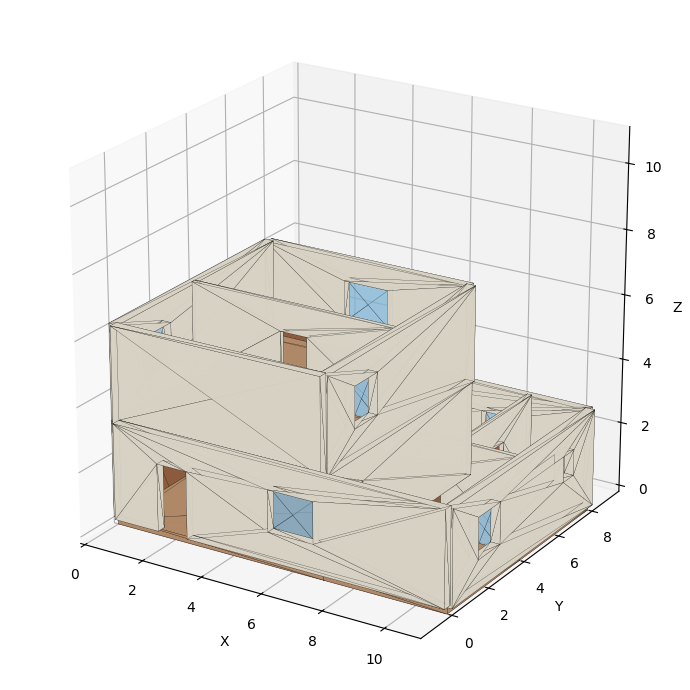

In [ ]:
# Optional: quick isometric preview so you can sanity-check before opening in a BIM tool.
import ifcopenshell, ifcopenshell.geom, numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

m = ifcopenshell.open(path)
s = ifcopenshell.geom.settings(); s.set("use-world-coords", True)
colors = {"IfcWall":"#d8d2c4","IfcSlab":"#b08968","IfcDoor":"#8c5a3c","IfcWindow":"#7fb3d5"}
fig = plt.figure(figsize=(9,7)); ax = fig.add_subplot(111, projection="3d")
allv = []
for cls, col in colors.items():
    for p in m.by_type(cls):
        if not getattr(p, "Representation", None): continue
        shp = ifcopenshell.geom.create_shape(s, p)
        v = np.array(shp.geometry.verts).reshape(-1,3); allv.append(v)
        f = np.array(shp.geometry.faces).reshape(-1,3)
        ax.add_collection3d(Poly3DCollection(v[f], facecolor=col, edgecolor="k",
                            linewidths=0.15, alpha=0.5 if cls=="IfcWindow" else 0.95))
allv = np.vstack(allv)
lo, hi = allv.min(0), allv.max(0); span = (hi-lo).max()
mid = (hi+lo)/2
ax.set_xlim(mid[0]-span/2, mid[0]+span/2)
ax.set_ylim(mid[1]-span/2, mid[1]+span/2)
ax.set_zlim(lo[2], lo[2]+span)
ax.set_box_aspect((1,1,1)); ax.view_init(elev=22, azim=-58)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.tight_layout(); plt.show()